In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn, optim

torch.manual_seed(42)
X = torch.linspace(-3, 3, 300).reshape(-1, 1)
y = torch.sin(X) + torch.randn(300, 1) * 0.15

# Create the neural network
first_layer = nn.Linear(1, 16) # Linear transformation 1
activation_layer = nn.ReLU() # Neuron activation
second_layer = nn.Linear(16, 1) # Linear transformation 2

# Define model by stacking layers in order
model = nn.Sequential(
    first_layer,
    activation_layer,
    second_layer
)

loss_function = nn.MSELoss() # Define the loss function
optimizer = optim.SGD(model.parameters(), lr=0.05) # Set up an optimizer to optimize weights and biases

for epoch in range(2000):
  y_pred = model(X) # Make a prediction by passing X to the model
  loss = loss_function(y_pred, y) # Calculate loss by passing y and y_pred
  loss.backward() # Calculate gradients
  optimizer.step() # Update weights and biases
  optimizer.zero_grad() # Reset

i = 0

for param in model.parameters():
  print(f"Param {i} = {param}")
  i += 1


Param 0 = Parameter containing:
tensor([[ 0.6712],
        [ 0.9534],
        [-0.2941],
        [ 0.2076],
        [-0.6638],
        [-0.3036],
        [ 0.6407],
        [ 0.5827],
        [-0.6141],
        [-0.8600],
        [-0.7654],
        [-0.8972],
        [-0.8189],
        [-0.1853],
        [ 0.5840],
        [ 0.1616]], requires_grad=True)
Param 1 = Parameter containing:
tensor([-1.0979, -0.9074,  0.6107, -0.7438, -0.1526,  0.6306, -0.8155,  0.0734,
        -0.0432,  0.0523, -0.3401, -1.2811, -0.8509, -0.5563,  1.2130, -0.4849],
       requires_grad=True)
Param 2 = Parameter containing:
tensor([[-0.8109, -0.3554, -0.4419,  0.1370,  0.0919, -0.4893, -0.6144,  0.2726,
         -0.0076, -0.2282,  0.0391,  0.8598,  0.3966, -0.1267,  0.7059,  0.0101]],
       requires_grad=True)
Param 3 = Parameter containing:
tensor([-0.2729], requires_grad=True)


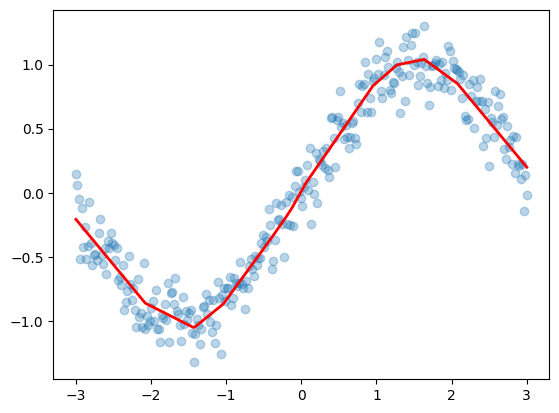

In [ ]:
plt.scatter(X.detach(), y.detach(), alpha=0.3) # Plot the data points
plt.plot(X.detach(), model(X).detach(), color='red', linewidth=2) # Plot the fitted line
plt.show()